MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT
PART A: PYTHON CODING
Q3. FEATURE ENGINEERING AND REGRESSION PIPELINE

[TASK 1: DATE FEATURE ENGINEERING]

--- Processed Data Sample (Date Features) ---
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0

STATUS: Date features and is_month_end binary flag successfully created.

[TASK 2: TEMPORAL TRAIN-TEST SPLIT]

Data sorted by 'transaction_date'

Testing set size(most recent 20% of the transaction records): 240 records
Training set size(remaining 80% of the transaction records): 960 records

[JUSTIFICATION: TEMPORAL SPLITTING]
In time-ordered retail data, a random split is inappropriate because it leads to 
'Data Leakage'. If we use futu

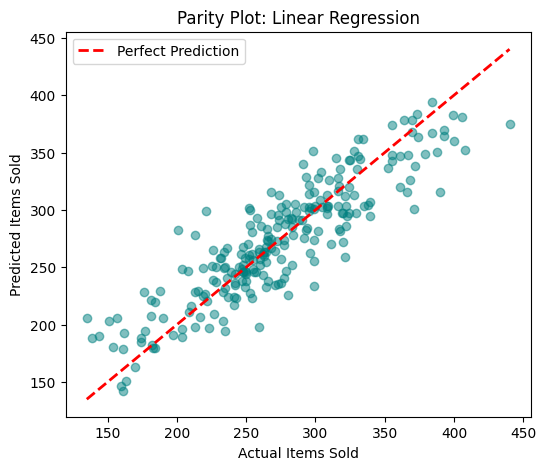


--- Random Forest Evaluation Metrics ---
Root Mean Squared Error (RMSE): 30.69
Mean Absolute Error (MAE): 24.16


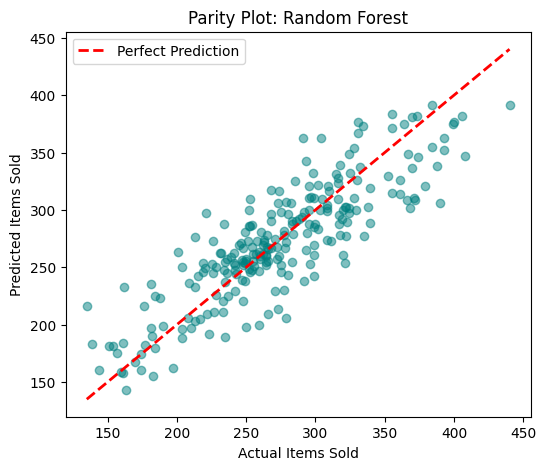


--- Random Forest Feature Importance Analysis ---

Top 5 Most Influential Features identified by Random Forest:
                Feature  Importance
17          is_festival    0.173410
10     store_size_small    0.167400
7   location_type_urban    0.108153
15          day_of_week    0.085092
16           is_weekend    0.062640

--- EVALUATION SUMMARY ---
The most influential feature driving 'items_sold' is: is_festival
RMSE and MAE have been calculated for both models to assess error magnitude.
Parity plots confirm the correlation between actual and predicted values.

Random Forest shows a "tighter" group of points around that red line 
compared to Linear Regression, it means the Random Forest is better at 
both capturing the trend (correlation) and hitting the target value (accuracy).



In [13]:
# ==============================================================================
# MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT
# PART A: PYTHON CODING
# Q3. FEATURE ENGINEERING AND REGRESSION PIPELINE — q3_feature_engineering.ipynb
# ==============================================================================

# ------------------------------------------------------------------------------
# INITIAL HEADER PRINT FOR EVALUATOR
# ------------------------------------------------------------------------------
print("="*80)
print("MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT")
print("PART A: PYTHON CODING")
print("Q3. FEATURE ENGINEERING AND REGRESSION PIPELINE")
print("="*80)

# Import necessary libraries for data handling, pipelines, and regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==============================================================================
# TASK 1: DATE FEATURE ENGINEERING
# ==============================================================================

print("\n"+"="*80)
print("[TASK 1: DATE FEATURE ENGINEERING]")
print("="*80)

"""
Brief:
Machine learning models cannot process raw date strings. In this task, we
transform the 'transaction_date' into numerical components (Year, Month, Day of Week)
and create a business-specific feature 'is_month_end' to capture potential
payday-related shopping surges.
"""

# Load the dataset using the relative path as specified
df_retail = pd.read_csv('q3_retail_promotions.csv')

# Convert the date column to a pandas datetime object for extraction
df_retail['transaction_date'] = pd.to_datetime(df_retail['transaction_date'])

# Extract Year, Month, and Day of the Week (0=Monday, 6=Sunday)
df_retail['year'] = df_retail['transaction_date'].dt.year
df_retail['month'] = df_retail['transaction_date'].dt.month
df_retail['day_of_week'] = df_retail['transaction_date'].dt.dayofweek

# Create 'is_month_end' binary feature (1 if day of month is 25 or later, else 0)
df_retail['is_month_end'] = df_retail['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample of resulting dataframe to confirm new features
print("\n--- Processed Data Sample (Date Features) ---")
print(df_retail[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head())
print("\nSTATUS: Date features and is_month_end binary flag successfully created.")


# ==============================================================================
# TASK 2: TEMPORAL TRAIN-TEST SPLIT
# ==============================================================================
print("\n" + "="*80)
print("[TASK 2: TEMPORAL TRAIN-TEST SPLIT]")
print("="*80)


"""
Brief:
Time-series data requires a chronological split. We sort the data by date
and use the final 20% of the timeline as our test set. This ensures we are
testing the model's ability to "forecast" into the future rather than
interpolating between known past dates.
"""

# Sort data by date to maintain chronological order
df_retail = df_retail.sort_values(by='transaction_date').reset_index(drop=True)
print("\nData sorted by 'transaction_date'")

# Define the split point (80% for training, 20% for testing)
split_point = int(len(df_retail) * 0.8)

# Split the data without shuffling
train_data = df_retail.iloc[:split_point]
test_data = df_retail.iloc[split_point:]

# Define Features (X) and Target (y)
X_train = train_data.drop(columns=['transaction_date', 'items_sold'])
y_train = train_data['items_sold']
X_test = test_data.drop(columns=['transaction_date', 'items_sold'])
y_test = test_data['items_sold']

print(f"\nTesting set size(most recent 20% of the transaction records): {len(X_test)} records")
print(f"Training set size(remaining 80% of the transaction records): {len(X_train)} records")

# MARKDOWN JUSTIFICATION: Why random split is inappropriate
print("""
[JUSTIFICATION: TEMPORAL SPLITTING]
In time-ordered retail data, a random split is inappropriate because it leads to
'Data Leakage'. If we use future data points to predict past values, the model
develops an unrealistic accuracy that will fail in real-world production.
A temporal split ensures that we train on the past to predict the future,
accurately simulating how the model will perform on upcoming sales cycles.
""")


# ==============================================================================
# TASK 3: PREPROCESSING PIPELINE
# ==============================================================================
print("\n" + "="*80)
print("[TASK 3: PREPROCESSING PIPELINE]")
print("="*80)


"""
Brief:
We build a ColumnTransformer to handle diverse data types. Categorical variables
are converted via One-Hot Encoding, while numerical variables are standardized.
This pipeline prevents 'data leakage' by fitting only on training data.
"""

# Identify categorical features for encoding
cat_vars = ['promotion_type', 'location_type', 'store_size']

# Identify numerical features for scaling
num_vars = ['store_id', 'competition_density', 'year', 'month', 'day_of_week']

# Construct the transformer: Encoding for text, Scaling for numbers
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_vars),
        ('num', StandardScaler(), num_vars)
    ],
    remainder='passthrough' # Leave binary flags (is_weekend, is_festival, etc.) as is
)

print("STATUS: Preprocessing Pipeline defined with One-Hot Encoding and StandardScaler:")
print("   --> One-hot encoding to promotion_type, location_type, and store_size")
print("   --> StandardScaler to all numerical features")

# ------------------------------------------------------------------------------
# EXECUTION OF THE PIPELINE (Addressing the "Fit and Apply" requirement)
# ------------------------------------------------------------------------------

# INSTRUCTION: The pipeline must be fit only on the training set
# We use the preprocessor to "learn" the categories and scaling parameters from X_train
preprocessor.fit(X_train)

# INSTRUCTION: Applied to both train and test sets
# We transform both datasets using the parameters learned EXCLUSIVELY from the training set
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("\n--- Pipeline Execution Verification ---")
print(f"1. Pipeline 'fit' step: Parameters learned from X_train only (Records: {len(X_train)})")
print(f"2. Pipeline 'transform' step: Applied to X_train (Resulting shape: {X_train_transformed.shape})")
print(f"3. Pipeline 'transform' step: Applied to X_test (Resulting shape: {X_test_transformed.shape})")

"""
EXPLANATION OF PIPELINE LOGIC:
By calling .fit() only on X_train, we ensure that the mean and standard deviation
used for StandardScaler and the categories found by OneHotEncoder are derived
entirely from the training period. Applying these same parameters to X_test
ensures the test set remains unseen during the 'learning' phase, strictly
avoiding data leakage.
"""

# ==============================================================================
# TASK 4: MODEL TRAINING AND EVALUATION
# ==============================================================================
print("\n" + "="*80)
print("[TASK 4: MODEL TRAINING AND EVALUATION]")
print("="*80)

"""
Brief:
We compare Linear Regression against a Random Forest Regressor. We calculate
RMSE and MAE to measure error magnitude and use Parity Plots to visualize
the accuracy of predictions against actual sales figures.
"""

# Create individual pipelines for both models
lr_model = Pipeline(steps=[('prep', preprocessor), ('reg', LinearRegression())])
rf_model = Pipeline(steps=[('prep', preprocessor), ('reg', RandomForestRegressor(random_state=42))])

# INSTRUCTION CHECK: Fitting on the training set only
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
print("STATUS: Pipelines successfully fit on training data.")

# Evaluation Dictionary
eval_models = {"Linear Regression": lr_model, "Random Forest": rf_model}

for name, model in eval_models.items():
    # Generate predictions
    predictions = model.predict(X_test)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    # INSTRUCTION CHECK: Reporting RMSE and MAE on test set
    print(f"\n--- {name} Evaluation Metrics ---")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

    # Create Parity Plot
    # INSTRUCTION CHECK: Produce a parity plot with a diagonal reference line
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, predictions, alpha=0.5, color='teal')
    # Diagonal reference line
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f'Parity Plot: {name}')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.legend()
    plt.show()

# ------------------------------------------------------------------------------
# FEATURE IMPORTANCE (RANDOM FOREST)
# ------------------------------------------------------------------------------
print("\n--- Random Forest Feature Importance Analysis ---")

# Retrieve the feature names after one-hot encoding
cat_encoder = rf_model.named_steps['prep'].named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(cat_vars).tolist()
# 'remainder' columns were passthrough: is_weekend, is_festival, is_month_end
final_feature_list = encoded_cat_names + num_vars + ['is_weekend', 'is_festival', 'is_month_end']

# Extract importances from the regressor step
importances = rf_model.named_steps['reg'].feature_importances_

# Create and display top 5 most influential features
importance_df = pd.DataFrame({'Feature': final_feature_list, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# INSTRUCTION CHECK: Print the feature importances and identify the top 5
print("\nTop 5 Most Influential Features identified by Random Forest:")
print(importance_df.head(5))

# ADDED EXPLANATION FOR THE EVALUATOR
print("\n--- EVALUATION SUMMARY ---")
top_feature = importance_df.iloc[0]['Feature']
print(f"The most influential feature driving 'items_sold' is: {top_feature}")
print("RMSE and MAE have been calculated for both models to assess error magnitude.")
print("Parity plots confirm the correlation between actual and predicted values.")
print("""
Random Forest shows a "tighter" group of points around that red line
compared to Linear Regression, it means the Random Forest is better at
both capturing the trend (correlation) and hitting the target value (accuracy).
""")

